In [20]:
# Import necessary libraries

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm
import cvxpy as cp

# Algorithms

## CLASP-I

In [3]:
class CLASP_I:
    
    def __init__(self, x_0, T, assumptions_param):
        
        self.x_0 = x_0        # Initial guess
        self.n = x_0.shape[0] # Optmization variable in R^n
    
    
    def projection_step(self, data):
        
        w_pred, x_tilde, label = data
        
        y = cp.Variable((self.n,1))
        cost = (1/2) * cp.norm(y - w_pred)**2

        constraints = []
        constraints.append(cp.norm(y) <= 70 * np.sqrt(self.n))
        
        if label == 1:
            constraints.append(y.T @ x_tilde >= 1.)
        else:
            constraints.append(y.T @ x_tilde <= -1.)

        prob = cp.Problem(cp.Minimize(cost), constraints)
        prob.solve()

        return y.value.copy()
        
    
    
    def run(self, dataset):
        
        # Start with initial guess
        w_pred = self.x_0.copy()
        
        # Save predictions and gradients
        Preds = [w_pred.flatten()]
        f_t_grads = np.zeros(w_pred.shape)
        
        # Obtain data
        features, labels = dataset
        
        step = 1
        for t in range(T):
            
            # Observe f_t and g_t
            x, y = features[t], labels[t]
            x_tilde = np.concatenate((x, [-1.])).reshape(-1,1)
            
            # Construct gradient of cost function
            f_grad = w_pred.copy()
            f_grad[-1] = 0.0
            
            # Update step
            w_pred = w_pred - (1/np.sqrt(t+1)) * f_grad
            
            # Projection step
            data = (w_pred, x_tilde, y)
            w_pred = self.projection_step(data)
                
            ## Save decision
            Preds.append(w_pred.flatten())
        
        # Return last decision and set of decisions
        return w_pred, Preds

## AdaGrad

In [4]:
class adv_AdaGrad:
    
    def __init__(self, x_0, T, assumptions_param):
        
        self.x_0 = x_0        # Initial guess
        self.n = x_0.shape[0] # Optmization variable in R^n
        
        # Assumptions parameters:
        # F denotes the Lipschitz constant of the cost functions
        # G denotes the Lipschitz constant of the constraint functions
        # D denotes the diameter of the static domain set
        self.F, self.G, self.D = assumptions_param
        
        # Algorithm parameters
        self.G_temp = max(self.F, self.G)
        self.V = 1
        self.beta = 1 / (2 * self.G_temp * self.D)
        self.lameda = 1 / (2 * np.sqrt(T))
        
        self.Q = 0.0
    
    
    def _Phi_grad(self, x):
        # Derivative of the non-decreasing convex Lyapunov function $\Phi(x) = x^2$
        return self.lameda * np.exp(self.lameda * x)
    
    
    def run(self, dataset):
        
        # Start with initial guess
        w_pred = self.x_0.copy()
        
        # Save predictions and gradients
        Preds = [w_pred.flatten()]
        f_t_grads = np.zeros(w_pred.shape)
        f_t_grads_norms = 0.0
        
        # Obtain data
        features, labels = dataset
        
        for i in range(T):
            
            # Observe f_t and g_t
            x, y = features[i], labels[i]
            f_t = 1/2 * np.linalg.norm(w_pred[:-1])**2
            x_tilde = np.concatenate((x, [-1.])).reshape(-1,1)
            g_t = -y * (w_pred.T @ x_tilde) + 1
            g_t = max(g_t[0], 0.0)
            
            # Update CCV
            self.Q = self.Q + self.beta * g_t
            
            # Construct gradient of surrogate function
            g_grad = np.zeros((self.n,1))
            if g_t > 0.0:
                g_grad = -y * x_tilde
            f_grad = w_pred.copy()
            f_grad[-1] = 0.0
        
            g_grad, f_grad = self.beta * g_grad, self.beta * f_grad

            f_hat_t_grad = self.V * f_grad + self._Phi_grad(self.Q) * g_grad
            f_t_grads_norms += np.linalg.norm(f_hat_t_grad)**2
            
            # AdaGrad step
            
            ## Update and project
            eta_t = (np.sqrt(2) * D) / (2 * np.sqrt(f_t_grads_norms))
            #eta_t = 1 / (i+1)
            
            w_pred = w_pred - eta_t * f_hat_t_grad
            
            if np.linalg.norm(w_pred) > 70 * np.sqrt(self.n):
                w_pred = (70 * np.sqrt(self.n) / np.linalg.norm(w_pred)) * w_pred
                
            ## Save decision
            Preds.append(w_pred.flatten())
        
        # Return last decision and set of decisions
        return w_pred, Preds

In [ ]:
#ADAMX

class adv_AdaGrad:
    
    def __init__(self, x_0, T, assumptions_param):
        
        self.x_0 = x_0        # Initial guess
        self.n = x_0.shape[0] # Optmization variable in R^n
        
        # Assumptions parameters:
        # F denotes the Lipschitz constant of the cost functions
        # G denotes the Lipschitz constant of the constraint functions
        # D denotes the diameter of the static domain set
        self.F, self.G, self.D = assumptions_param
        
        # Algorithm parameters
        self.G_temp = max(self.F, self.G)
        self.V = 1
        self.beta = 1 / (2 * self.G_temp * self.D)
        self.lameda = 1 / (2 * np.sqrt(T))
        
        self.Q = 0.0
    
    
    
    
    def run(self, dataset):
        
        # Start with initial guess
        w_pred = self.x_0.copy()
        
        # Save predictions and gradients
        Preds = [w_pred.flatten()]
        f_t_grads = np.zeros(w_pred.shape)
        f_t_grads_norms = 0.0
        
        # Obtain data
        features, labels = dataset
        
        for i in range(T):
            
            # Observe f_t and g_t
            x, y = features[i], labels[i]
            f_t = 1/2 * np.linalg.norm(w_pred[:-1])**2
            x_tilde = np.concatenate((x, [-1.])).reshape(-1,1)
            g_t = -y * (w_pred.T @ x_tilde) + 1
            g_t = max(g_t[0], 0.0)
            
            # Update CCV
            self.Q = self.Q + self.beta * g_t
            
            # Construct gradient of surrogate function
            g_grad = np.zeros((self.n,1))
            if g_t > 0.0:
                g_grad = -y * x_tilde
            f_grad = w_pred.copy()
            f_grad[-1] = 0.0
        
            g_grad, f_grad = self.beta * g_grad, self.beta * f_grad

            f_hat_t_grad = self.V * f_grad + self._Phi_grad(self.Q) * g_grad
            f_t_grads_norms += np.linalg.norm(f_hat_t_grad)**2
            
            # AdaGrad step
            
            ## Update and project
            eta_t = (np.sqrt(2) * D) / (2 * np.sqrt(f_t_grads_norms))
            #eta_t = 1 / (i+1)
            
            w_pred = w_pred - eta_t * f_hat_t_grad
            
            if np.linalg.norm(w_pred) > 70 * np.sqrt(self.n):
                w_pred = (70 * np.sqrt(self.n) / np.linalg.norm(w_pred)) * w_pred
                
            ## Save decision
            Preds.append(w_pred.flatten())
        
        # Return last decision and set of decisions
        return w_pred, Preds

## CLASP-F

In [5]:
class CLASP_F:
    
    def __init__(self, x_0, T, assumptions_param):
        
        self.x_0 = x_0        # Initial guess
        self.n = x_0.shape[0] # Optmization variable in R^n
        
        
    def projection_step(self, y):
        
        if np.linalg.norm(y) > 70 * np.sqrt(self.n):
                y = (70 * np.sqrt(self.n) / np.linalg.norm(y)) * y
        return y.copy()
    
    def run(self, dataset):
        
        # Start with initial guess
        w_pred = self.x_0.copy()
        
        # Save predictions and gradients
        Preds = [w_pred.flatten()]
        f_t_grads = np.zeros(w_pred.shape)
        
        # Obtain data
        features, labels = dataset
        
        step = 1
        for t in range(T):
            
            # Observe f_t and g_t
            x, y = features[t], labels[t]
            f_t = 1/2 * np.linalg.norm(w_pred[:-1])**2
            x_tilde = np.concatenate((x, [-1.])).reshape(-1,1)
            g_t = -y * (w_pred.T @ x_tilde) + 1
            g_t = max(g_t[0], 0.0)
            
            # Construct gradient of cost and constraint functions
            g_grad = np.zeros((self.n,1))
            if g_t > 0.0:
                g_grad = -y * x_tilde
            
            # Intermediate step
            bar_x = w_pred
            if g_t > 0.0:
                bar_x = bar_x - (g_t / np.linalg.norm(g_grad)**2) * g_grad
            bar_x = self.projection_step(bar_x)
            
            # Update and projection step
            f_grad = bar_x.copy()
            f_grad[-1] = 0.0
            w_pred = bar_x - (1/np.sqrt(t+1)) * f_grad
            w_pred = self.projection_step(w_pred)
                
            ## Save decision
            Preds.append(w_pred.flatten())
        
        # Return last decision and set of decisions
        return w_pred, Preds

## RECOO

In [6]:
class adv_RECOO:
    
    def __init__(self, x_0, T, assumptions_param):
        
        self.x_0 = x_0        # Initial guess
        self.n = x_0.shape[0] # Optmization variable in R^n
        
        # Assumptions parameters:
        # F denotes the Lipschitz constant of the cost functions
        # G denotes the Lipschitz constant of the constraint functions
        # D denotes the diameter of the static domain set
        self.F, self.G, self.D = assumptions_param
        
        # Algorithm parameters
        self.G_temp = max(self.F, self.G)
        
        self.Q = 0.0
    
    
    def run(self, dataset):
        
        # Start with initial guess
        w_pred = self.x_0.copy()
        
        # Save predictions and gradients
        Preds = [w_pred.flatten()]
        
        # Obtain data
        features, labels = dataset
        
        for t in range(T):
            
            # Parameters
            alpha_t = cp.sqrt(t+1)
            eta_t = np.sqrt(t+1)
            epsilon = 1e-3
            gamma_t = cp.power(t, 0.5 * epsilon)
            
            x_var = cp.Variable((self.n,1))
            
            # Observe f_t and g_t
            x, y = features[t], labels[t]
            x_tilde = np.concatenate((x, [-1.])).reshape(-1,1)
            g_t = -y * (w_pred.T @ x_tilde) + 1
            g_t = max(g_t[0], 0.0)
            
            self.Q = max(self.Q + g_t, eta_t)
            
            
            id_mat = np.identity(self.n)
            id_mat[self.n-1, self.n-1] = 0.0
            f_grad = id_mat @ w_pred
            g_t_fun = -y * (w_pred.T @ x_var) + 1
            g_t_tilde = gamma_t * cp.maximum(g_t_fun[0][0], 0.0)
            
            x_tilde = np.concatenate((x, [-1.])).reshape(-1,1)
            
            constraints = [cp.norm(x_var) <= 70 * cp.sqrt(self.n)]
            
            cost = f_grad.T @ x_var + self.Q * g_t_tilde + alpha_t * cp.norm(x_var - w_pred)**2
            
            prob = cp.Problem(cp.Minimize(cost), constraints)
            prob.solve()
            
            w_pred = x_var.value.copy()

            ## Save decision
            Preds.append(w_pred.flatten())
        
        # Return last decision and set of decisions
        return w_pred, Preds

## Frank-Wolfe

In [7]:
class adv_FrankWolfe:
    
    def __init__(self, x_0, T, assumptions_param):
        
        self.x_0 = x_0        # Initial guess
        self.n = x_0.shape[0] # Optmization variable in R^n
        
        # Assumptions parameters:
        # F denotes the Lipschitz constant of the cost functions
        # G denotes the Lipschitz constant of the constraint functions
        # D denotes the diameter of the static domain set
        self.F, self.G, self.D = assumptions_param
        
        # Algorithm parameters
        self.G_temp = max(self.F, self.G)
        self.beta = 1 / ((2**6) * self.G_temp * self.D)
        self.lameda = 1 / (2 * (T**(3/4)))
        self.gamma = 1
        
        self.Q = 0.0
    
    
    def _Phi_grad(self, x):
        # Derivative of the non-decreasing convex Lyapunov function $\Phi(x) = x^2$
        return self.lameda * np.exp(self.lameda * x)
    
    
    def _optimization_step(self, data):
        
        f_t_grads, x_s_k, eta_t, s_k = data
        
        x_var = cp.Variable(f_t_grads[0].shape)
        
        F_grad = -2 * x_s_k
        for f_sup_grad in f_t_grads[s_k - 1:]:
            F_grad += eta_t * f_sup_grad
        
        cost = 2 * cp.square(cp.norm(x_var)) + F_grad.T @ x_var
        
        constraints = [cp.norm(x_var) <= 70 * np.sqrt(self.n)]

        prob = cp.Problem(cp.Minimize(cost), constraints)
        prob.solve()

        return x_var.value.copy()
    
    
    def run(self, dataset):
        
        # Start with initial guess
        x_pred = self.x_0.copy()
        
        # Save predictions and gradients
        Preds = [x_pred.flatten()]
        f_t_grads = []
        f_t_grads_norms = 0.0
        
        # Obtain data
        features, labels = dataset
        
        # Frank-Wolfe Auxiliary variables
        G_k = 1
        s_k = 1
        x_s_k = x_pred.copy()
        
        for i in range(T):
            # Observe f_t and g_t
            x, y = features[i], labels[i]
            f_t = 1/2 * np.linalg.norm(x_pred[:-1])**2
            x_tilde = np.concatenate((x, [-1.])).reshape(-1,1)
            g_t = -y * (x_pred.T @ x_tilde) + 1
            g_t = max(g_t[0], 0.0)
            
            # Update CCV
            self.Q = self.Q + g_t
            
            ## Apply Frank-Wolfe-based algorithm
            
            while G_k < self.beta * self.G_temp * (self.gamma + self._Phi_grad(self.beta * self.Q)):
                G_k = G_k * 2
                s_k = i + 1
                x_s_k = x_pred.copy()
                
            # Construct gradient of surrogate function
            g_grad = np.zeros((self.n,1))
            if g_t > 0.0:
                g_grad = -y * x_tilde
            f_grad = x_pred.copy()
            f_grad[-1] = 0.0
            
            eta_t = self.D / (2 * G_k * T**(3/4))
            
            f_tilde_grad = self.gamma * self.beta * f_grad + self._Phi_grad(self.beta * self.Q) * self.beta * g_grad
            f_t_grads.append(f_tilde_grad)
            
            data = (f_t_grads, x_s_k, eta_t, s_k)
            
            v_pred = self._optimization_step(data)
            sigma = 2 / np.sqrt(i + 1 - s_k + 1)
            
                
            x_pred = x_pred + sigma * (v_pred - x_pred)
            
            Preds.append(x_pred.flatten())
        
        # Return last decision and set of decisions
        return x_pred, Preds

# Run Single Experiment

## Import Wine Dataset

In [18]:
import numpy as np
from sklearn.datasets import load_wine

# Load dataset
wine = load_wine()
features = wine.data          # shape: (n_samples, n_features)
labels = wine.target          # shape: (n_samples,)

# Combine for shuffling (important to keep alignment)
dataset = np.hstack([features, labels.reshape(-1, 1)])

n = features.shape[1]
T = features.shape[0]

F = 70 * np.sqrt(n)
G = 70 * np.sqrt(n)
D = 140 * np.sqrt(n)

In [36]:
features.shape

(178, 13)

## CLASP-I

In [21]:
assumptions_param = (F, G, D)

#Initial guess
x_0 = np.random.uniform(-1.0, 1.0, size=n+1).reshape(-1,1)
data = (features, labels)


CLASP_I_alg = CLASP_I(x_0.copy(), T, assumptions_param)
_, Preds = CLASP_I_alg.run(data)

In [22]:
Preds_dict = {}
Preds_dict["CLASP_I"] = Preds

In [23]:
def compute_cost_and_ccv(features, labels, Preds):
    Cost_sum = 0.0
    Cost_arr = []
    CCV_sum = 0.0
    CCV_arr = [0.0]
    CCV_2_sum = 0.0
    CCV_2_arr = [0.0]
    
    step = 1
    for i in range(T):
        w_pred = Preds[i].reshape(-1,1)
        f_t = 1/2 * np.linalg.norm(w_pred[:-1])**2
        Cost_sum += f_t
        Cost_arr.append(Cost_sum)
        
        x, y = features[i], labels[i]
        x_tilde = np.concatenate((x, [-1.])).reshape(-1,1)
        g_t = -y * (w_pred.T @ x_tilde) + 1
        
        pen = max(g_t[0][0], 0.0)
        
        CCV_sum += pen
        CCV_arr.append(CCV_sum)
        
        CCV_2_sum += pen**2
        CCV_2_arr.append(CCV_2_sum)
    
    return Cost_arr, CCV_arr, CCV_2_arr

In [24]:
# Obtain data
features, labels = data

Cost_CLASP_I, CCV_CLASP_I, CCV_2_CLASP_I = compute_cost_and_ccv(features, labels, Preds)

In [25]:
def plot_regret(regrets, labels):
    
    # Plot list of regrets
    if len(regrets) != len(labels):
        raise Exception("Length of regrets must be the same as labels")
    
    ts = np.linspace(1,T,T)
    for i in range(len(regrets)):
        plt.plot(ts, regrets[i], label = labels[i], alpha=0.5)
    
    plt.ylabel('Cumulative loss')
    plt.xlabel('$t$ (iterations)')
    plt.yscale('symlog')
    plt.legend()
    

def plot_ccv(ccvs, labels, y_label = '$CCV_{T,1}(t)$'):
    # Plot list of CCV
    if len(ccvs) != len(labels):
        raise Exception("Length of ccvs must be the same as labels")
    
    ts = np.linspace(0,T,T+1)
    for i in range(len(ccvs)):
        plt.plot(ts, ccvs[i], label = labels[i])
    
    plt.ylabel(y_label)
    plt.xlabel('$t$ (iterations)')
    plt.yscale('symlog')
    plt.legend()

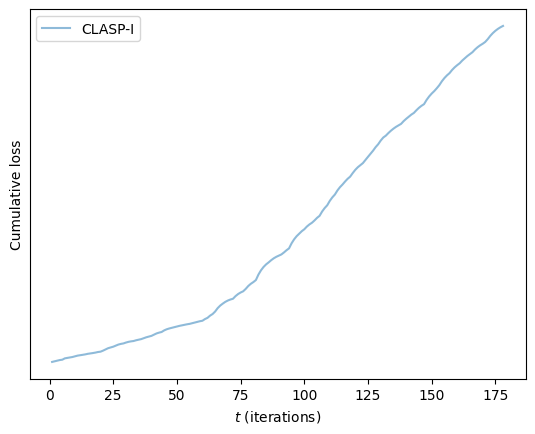

In [26]:
plot_regret([Cost_CLASP_I], ["CLASP-I"])

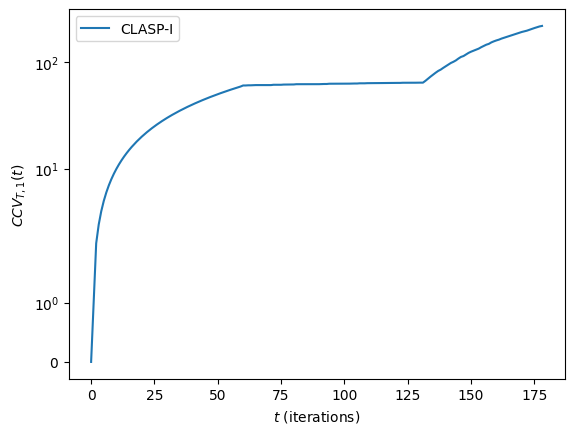

In [27]:
plot_ccv([CCV_CLASP_I], ["CLASP-I"])

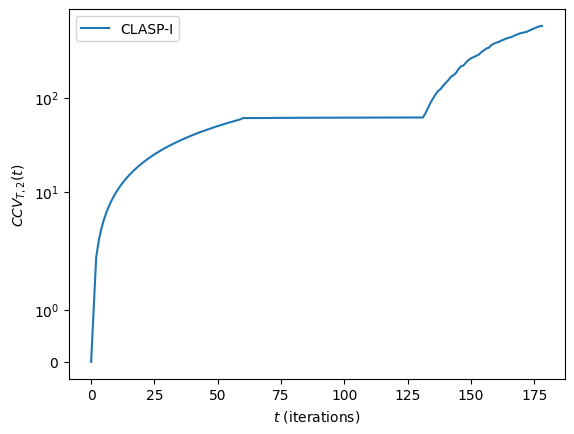

In [28]:
plot_ccv([CCV_2_CLASP_I], ["CLASP-I"], y_label='$CCV_{T,2}(t)$')

## Run AdaGrad

In [29]:
AdaGrad_alg = adv_AdaGrad(x_0.copy(), T, assumptions_param)
_, Preds = AdaGrad_alg.run(data)

In [30]:
Preds_dict["AdaGrad"] = Preds

In [31]:
# Compute regret and CCV
Cost_sum = 0.0
Cost_AdaGrad = []
CCV_sum = 0.0
CCV_AdaGrad = [0.0]

# Obtain data
features, labels = data

Cost_AdaGrad, CCV_AdaGrad, CCV_2_AdaGrad = compute_cost_and_ccv(features, labels, Preds)

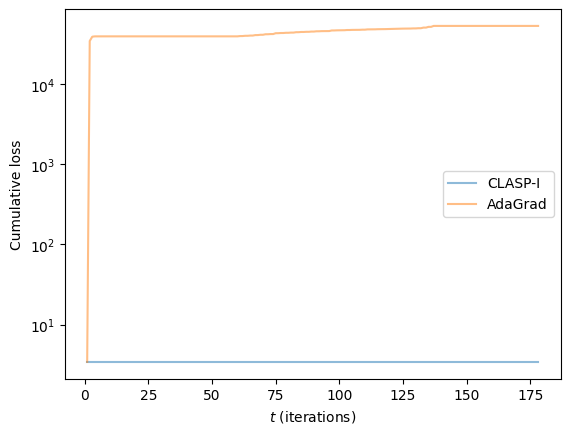

In [32]:
# Plot obtained cost at each round
plot_regret([Cost_CLASP_I, Cost_AdaGrad], ['CLASP-I', 'AdaGrad'])
plt.yscale('symlog')

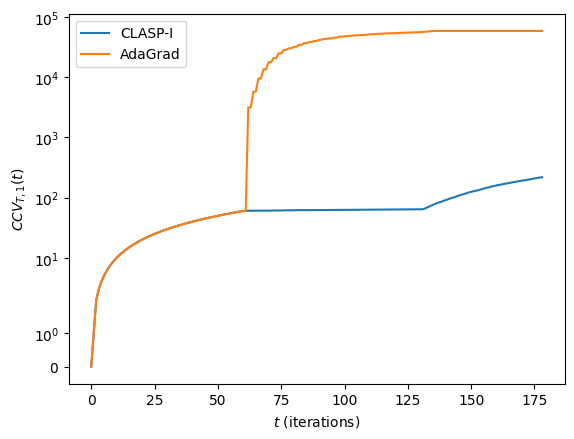

In [33]:
# Plot obtained CCV
plot_ccv([CCV_CLASP_I, CCV_AdaGrad], 
         ['CLASP-I', 'AdaGrad'])

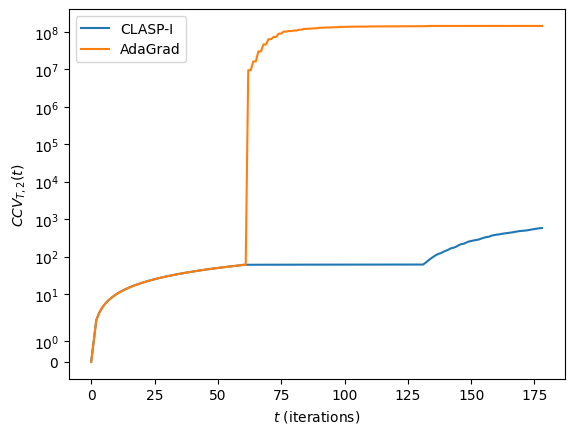

In [35]:
# Plot obtained CCV
plot_ccv([CCV_2_CLASP_I, CCV_2_AdaGrad], 
         ['CLASP-I', 'AdaGrad'], y_label='$CCV_{T,2}(t)$')

## Run RECOO

In [ ]:
RECOO_alg = adv_RECOO(x_0.copy(), T, assumptions_param)
_, Preds = RECOO_alg.run(data)

In [ ]:
Preds_dict["RECOO"] = Preds

In [ ]:
# Obtain data
features, labels = data

Cost_RECOO, CCV_RECOO, CCV_2_RECOO = compute_cost_and_ccv(features, labels, Preds)

In [ ]:
# Plot obtained cost at each round
plot_regret([Cost_CLASP_I, Cost_AdaGrad, Cost_RECOO], ['CLASP-I', 'AdaGrad', 'RECOO'])
plt.yscale('symlog')

In [ ]:
# Plot obtained CCV
plot_ccv([CCV_CLASP_I, CCV_AdaGrad, CCV_RECOO], 
         ['CLASP-I', 'AdaGrad', 'RECOO'])

In [ ]:
# Plot obtained CCV
plot_ccv([CCV_2_CLASP_I, CCV_2_AdaGrad, CCV_2_RECOO], 
         ['CLASP-I', 'AdaGrad', 'RECOO'], y_label='$CCV_{T,2}(t)$')

## Run Frank-Wolfe

In [ ]:
FW_alg = adv_FrankWolfe(x_0.copy(), T, assumptions_param)
_, Preds = FW_alg.run(data)

In [ ]:
Preds_dict["FW"] = Preds

In [ ]:
# Obtain data
features, labels = data

Cost_FW, CCV_FW, CCV_2_FW = compute_cost_and_ccv(features, labels, Preds)

In [ ]:
# Plot obtained cost at each round
plot_regret([Cost_CLASP_I, Cost_AdaGrad, Cost_RECOO, Cost_FW], 
            ['CLASP-I', 'AdaGrad', 'RECOO', 'Frank-Wolfe'])
plt.yscale('symlog')

In [ ]:
# Plot obtained CCV
plot_ccv([CCV_CLASP_I, CCV_AdaGrad, CCV_RECOO, CCV_FW], 
         ['CLASP-I', 'AdaGrad', 'RECOO', 'Frank-Wolfe'])

In [ ]:
# Plot obtained CCV
plot_ccv([CCV_2_CLASP_I, CCV_2_AdaGrad, CCV_2_RECOO, CCV_2_FW], 
         ['CLASP-I', 'AdaGrad', 'RECOO', 'Frank-Wolfe'], y_label='$CCV_{T,2}(t)$')

## Run CLASP-F

In [ ]:
CLASP_F_alg = CLASP_F(x_0.copy(), T, assumptions_param)
_, Preds = CLASP_F_alg.run(data)

In [ ]:
Preds_dict["CLASP_F"] = Preds

In [ ]:
# Obtain data
features, labels = data

Cost_CLASP_F, CCV_CLASP_F, CCV_2_CLASP_F = compute_cost_and_ccv(features, labels, Preds)

In [ ]:
# Plot obtained cost at each round
plot_regret([Cost_CLASP_I, Cost_AdaGrad, Cost_RECOO, Cost_FW, Cost_CLASP_F], 
            ['CLASP-I', 'AdaGrad', 'RECOO', 'Frank-Wolfe', 'CLASP-F'])
plt.yscale('symlog')

In [ ]:
# Plot obtained CCV
plot_ccv([CCV_CLASP_I, CCV_AdaGrad, CCV_RECOO, CCV_FW, CCV_CLASP_F], 
         ['CLASP-I', 'AdaGrad', 'RECOO', 'Frank-Wolfe', 'CLASP-F'])

In [ ]:
# Plot obtained CCV
plot_ccv([CCV_2_CLASP_I, CCV_2_AdaGrad, CCV_2_RECOO, CCV_2_FW, CCV_2_CLASP_F], 
         ['CLASP-I', 'AdaGrad', 'RECOO', 'Frank-Wolfe', 'CLASP-F'], y_label='$CCV_{T,2}(t)$')

# Run Multiple Experiments

In [ ]:
S = 50 # Run 50 trials

## Import wine dataset here
# dataset = ...

n = features.shape[1]
T = features.shape[0]

F = 70 * np.sqrt(n)
G = 70 * np.sqrt(n)
D = 140 * np.sqrt(n)

assumptions_param = (F, G, D)

Cost_dict = {'CLASP_F': [], 'FW': [], 'RECOO': [], 'AdaGrad': [], 'CLASP_I': []}
CCV_dict = {'CLASP_F': [], 'FW': [], 'RECOO': [], 'AdaGrad': [], 'CLASP_I': []}
CCV_2_dict = {'CLASP_F': [], 'FW': [], 'RECOO': [], 'AdaGrad': [], 'CLASP_I': []}

for _ in tqdm(range(S)):
    
    ## Shuffle wine dataset
    # np.random.shuffle(dataset)
    # features = ...
    # labels = ...
    
    #Initial guess
    x_0 = np.random.uniform(-1.0, 1.0, size=n+1).reshape(-1,1)
    data = (features, labels)

    # Run CLASP
    CLASP_I_alg = CLASP_I(x_0.copy(), T, assumptions_param)
    _, Preds = CLASP_I_alg.run(data)
    
    Cost_CLASP_I, CCV_CLASP_I, CCV_2_CLAS_IP = compute_cost_and_ccv(features, labels, Preds)
    Cost_dict['CLASP_I'].append(Cost_CLASP_I)
    CCV_dict['CLASP_I'].append(CCV_CLASP_I)
    CCV_2_dict['CLASP_I'].append(CCV_2_CLASP_I)
    
    # Run AdaGrad
    AdaGrad_alg = adv_AdaGrad(x_0.copy(), T, assumptions_param)
    _, Preds = AdaGrad_alg.run(data)
    
    Cost_AdaGrad, CCV_AdaGrad, CCV_2_AdaGrad = compute_cost_and_ccv(features, labels, Preds)
    Cost_dict['AdaGrad'].append(Cost_AdaGrad)
    CCV_dict['AdaGrad'].append(CCV_AdaGrad)
    CCV_2_dict['AdaGrad'].append(CCV_2_AdaGrad)
    
    # Run CLASP_F
    CLASP_F_alg = CLASP_F(x_0.copy(), T, assumptions_param)
    _, Preds = CLASP_F_alg.run(data)
    
    Cost_CLASP_F, CCV_CLASP_F, CCV_2_CLASP_F = compute_cost_and_ccv(features, labels, Preds)
    Cost_dict['CLASP_F'].append(Cost_CLASP_F)
    CCV_dict['CLASP_F'].append(CCV_CLASP_F)
    CCV_2_dict['CLASP_F'].append(CCV_2_CLASP_F)
    
    # Run RECOO
    RECOO_alg = adv_RECOO(x_0.copy(), T, assumptions_param)
    _, Preds = RECOO_alg.run(data)
    
    Cost_RECOO, CCV_RECOO, CCV_2_RECOO = compute_cost_and_ccv(features, labels, Preds)
    Cost_dict['RECOO'].append(Cost_RECOO)
    CCV_dict['RECOO'].append(CCV_RECOO)
    CCV_2_dict['RECOO'].append(CCV_2_RECOO)
    
    # Run Frank-Wolfe
    FW_alg = adv_FrankWolfe(x_0.copy(), T, assumptions_param)
    _, Preds = FW_alg.run(data)
    
    Cost_FW, CCV_FW, CCV_2_FW = compute_cost_and_ccv(features, labels, Preds)
    Cost_dict['FW'].append(Cost_FW)
    CCV_dict['FW'].append(CCV_FW)
    CCV_2_dict['FW'].append(CCV_2_FW)

In [ ]:
Cost_dict['AdaGrad'] = np.array(Cost_dict['AdaGrad'])
CCV_dict['AdaGrad'] = np.array(CCV_dict['AdaGrad'])
CCV_2_dict['AdaGrad'] = np.array(CCV_2_dict['AdaGrad'])

Cost_dict['CLASP_I'] = np.array(Cost_dict['CLASP_I'])
CCV_dict['CLASP_I'] = np.array(CCV_dict['CLASP_I'])
CCV_2_dict['CLASP_I'] = np.array(CCV_2_dict['CLASP_I'])

Cost_dict['CLASP_F'] = np.array(Cost_dict['CLASP_F'])
CCV_dict['CLASP_F'] = np.array(CCV_dict['CLASP_F'])
CCV_2_dict['CLASP_F'] = np.array(CCV_2_dict['CLASP_F'])

Cost_dict['RECOO'] = np.array(Cost_dict['RECOO'])
CCV_dict['RECOO'] = np.array(CCV_dict['RECOO'])
CCV_2_dict['RECOO'] = np.array(CCV_2_dict['RECOO'])

Cost_dict['FW'] = np.array(Cost_dict['FW'])
CCV_dict['FW'] = np.array(CCV_dict['FW'])
CCV_2_dict['FW'] = np.array(CCV_2_dict['FW'])

In [ ]:
SIZE = 18
plt.rc('axes', titlesize=SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SIZE-1)    # legend fontsize

# Plot mean cumulative cost for the different algorithms

In [ ]:
mean_cost_AdaGrad = np.mean(Cost_dict['AdaGrad'], axis=0)
std_cost_AdaGrad = 2 * np.std(Cost_dict['AdaGrad'], axis=0)

mean_cost_CLASP_I = np.mean(Cost_dict['CLASP_I'], axis=0)
std_cost_CLASP_I = 2 * np.std(Cost_dict['CLASP_I'], axis=0)

mean_cost_CLASP_F = np.mean(Cost_dict['CLASP_F'], axis=0)
std_cost_CLASP_F = 2 * np.std(Cost_dict['CLASP_F'], axis=0)

mean_cost_RECOO = np.mean(Cost_dict['RECOO'], axis=0)
std_cost_RECOO = 2 * np.std(Cost_dict['RECOO'], axis=0)

mean_cost_FW = np.mean(Cost_dict['FW'], axis=0)
std_cost_FW = 2 * np.std(Cost_dict['FW'], axis=0)

In [ ]:
ts = np.linspace(1,T,T)
plt.plot(ts, mean_cost_AdaGrad, label='AdaGrad')
plt.fill_between(ts, mean_cost_AdaGrad-std_cost_AdaGrad, mean_cost_AdaGrad+std_cost_AdaGrad, alpha=0.35)

plt.plot(ts, mean_cost_CLASP_I, label='CLASP-I')
plt.fill_between(ts, mean_cost_CLASP_I-std_cost_CLASP_I, mean_cost_CLASP_I+std_cost_CLASP_I, alpha=0.35)

plt.plot(ts, mean_cost_CLASP_F, label='CLASP-F')
plt.fill_between(ts, mean_cost_CLASP_F-std_cost_CLASP_F, mean_cost_CLASP_F+std_cost_CLASP_F, alpha=0.35)

plt.plot(ts, mean_cost_RECOO, label='RECOO')
plt.fill_between(ts, mean_cost_RECOO-std_cost_RECOO, mean_cost_RECOO+std_cost_RECOO, alpha=0.35)

plt.plot(ts, mean_cost_FW, label='Frank-Wolfe')
plt.fill_between(ts, mean_cost_FW-std_cost_FW, mean_cost_FW+std_cost_FW, alpha=0.2)

plt.ylabel('Cumulative loss')
plt.xlabel('$t$ (iterations)')
plt.yscale('log')
plt.legend(loc='lower right')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.savefig('Cost_classification.pdf', format='pdf', bbox_inches='tight')

# Plot mean CCV for the different algorithms

In [ ]:
mean_ccv_AdaGrad = np.mean(CCV_dict['AdaGrad'], axis=0)
std_ccv_AdaGrad = 2 * np.std(CCV_dict['AdaGrad'], axis=0)

mean_ccv_CLASP_I = np.mean(CCV_dict['CLASP_I'], axis=0)
std_ccv_CLASP_I = 2 * np.std(CCV_dict['CLASP_I'], axis=0)

mean_ccv_CLASP_F = np.mean(CCV_dict['CLASP_F'], axis=0)
std_ccv_CLASP_F = 2 * np.std(CCV_dict['CLASP_F'], axis=0)

mean_ccv_RECOO = np.mean(CCV_dict['RECOO'], axis=0)
std_ccv_RECOO = 2 * np.std(CCV_dict['RECOO'], axis=0)

mean_ccv_FW = np.mean(CCV_dict['FW'], axis=0)
std_ccv_FW = 2 * np.std(CCV_dict['FW'], axis=0)

In [ ]:
ts = np.linspace(0,T,T+1)

plt.plot(ts, mean_ccv_AdaGrad, label='AdaGrad')
plt.fill_between(ts, mean_ccv_AdaGrad-std_ccv_AdaGrad, mean_ccv_AdaGrad+std_ccv_AdaGrad, alpha=0.35)

plt.plot(ts, mean_ccv_CLASP_I, label='CLASP-I')
plt.fill_between(ts, mean_ccv_CLASP_I-std_ccv_CLASP_I, mean_ccv_CLASP_I+std_ccv_CLASP_I, alpha=0.35)

plt.plot(ts, mean_ccv_CLASP_F, label='CLASP-F')
plt.fill_between(ts, mean_ccv_CLASP_F-std_ccv_CLASP_F, mean_ccv_CLASP_F+std_ccv_CLASP_F, alpha=0.35)

plt.plot(ts, mean_ccv_RECOO, label='RECOO')
plt.fill_between(ts, mean_ccv_RECOO-std_ccv_RECOO, mean_ccv_RECOO+std_ccv_RECOO, alpha=0.35)

plt.plot(ts, mean_ccv_FW, label='Frank-Wolfe')
plt.fill_between(ts, mean_ccv_FW-std_ccv_FW, mean_ccv_FW+std_ccv_FW, alpha=0.2)

plt.yscale('log')
plt.ylabel('$CCV_{t,1}$')
plt.xlabel('$t$ (iterations)')
#plt.legend()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('CCV_{T,1}_classification.pdf', format='pdf', bbox_inches='tight')

In [ ]:
mean_ccv_2_AdaGrad = np.mean(CCV_2_dict['AdaGrad'], axis=0)
std_ccv_2_AdaGrad = 2 * np.std(CCV_2_dict['AdaGrad'], axis=0)

mean_ccv_2_CLASP_I = np.mean(CCV_2_dict['CLASP_I'], axis=0)
std_ccv_2_CLASP_I = 2 * np.std(CCV_2_dict['CLASP_I'], axis=0)

mean_ccv_2_CLASP_F = np.mean(CCV_2_dict['CLASP_F'], axis=0)
std_ccv_2_CLASP_F = 2 * np.std(CCV_2_dict['CLASP_F'], axis=0)

mean_ccv_2_RECOO = np.mean(CCV_2_dict['RECOO'], axis=0)
std_ccv_2_RECOO = 2 * np.std(CCV_2_dict['RECOO'], axis=0)

mean_ccv_2_FW = np.mean(CCV_2_dict['FW'], axis=0)
std_ccv_2_FW = 2 * np.std(CCV_2_dict['FW'], axis=0)

In [ ]:
ts = np.linspace(0,T,T+1)
plt.plot(ts, mean_ccv_2_AdaGrad, label='AdaGrad')
plt.fill_between(ts, mean_ccv_2_AdaGrad-std_ccv_2_AdaGrad, mean_ccv_2_AdaGrad+std_ccv_2_AdaGrad, alpha=0.35)

plt.plot(ts, mean_ccv_2_CLASP_I, label='CLASP-I')
plt.fill_between(ts, mean_ccv_2_CLASP_I-std_ccv_2_CLASP_I, mean_ccv_2_CLASP_I+std_ccv_2_CLASP_I, alpha=0.35)

plt.plot(ts, mean_ccv_2_CLASP_F, label='CLASP-F')
plt.fill_between(ts, mean_ccv_2_CLASP_F-std_ccv_2_CLASP_F, mean_ccv_2_CLASP_F+std_ccv_2_CLASP_F, alpha=0.35)

plt.plot(ts, mean_ccv_2_RECOO, label='RECOO')
plt.fill_between(ts, mean_ccv_2_RECOO-std_ccv_2_RECOO, mean_ccv_2_RECOO+std_ccv_2_RECOO, alpha=0.2)

plt.plot(ts, mean_ccv_2_FW, label='Frank-Wolfe')
plt.fill_between(ts, mean_ccv_2_FW-std_ccv_2_FW, mean_ccv_2_FW+std_ccv_2_FW, alpha=0.2)

plt.yscale('log')
plt.ylabel('$CCV_{t,2}$')
plt.xlabel('$t$ (iterations)')
#plt.legend()
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('CCV_{T,2}_classification.pdf', format='pdf', bbox_inches='tight')